In [1]:
# Cell 1:  Setup and imports

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.features import compute_all_iv, plot_default_rate_by_bin

Train: 84264 rows, Test: 36080


In [1]:
# Cell 2:  Load clean data, train/test split

df = pd.read_csv('../outputs/loan_book_clean.csv')

train = df[df["set"] == "train"].copy()
test = df[df["set"] == "test"].copy()

print(f"Train: {len(train)} rows, Test: {len(test)}")

Train: 84264 rows, Test: 36080


In [2]:
# Cell 3:  Compute IV for all features and create ranked table
exclude = ["applicant_id_hash", "default_flag", "set", "application_date"]

iv_summary = compute_all_iv(train, target="default_flag", exclude_cols=exclude)
print(iv_summary.to_string(index=False))

                      feature     iv
                interest_rate 0.4054
months_since_last_delinquency 0.4007
                annual_income 0.3650
                          age 0.2523
        num_delinquencies_2yr 0.2403
  months_since_oldest_account 0.2395
      employment_length_years 0.1613
         pct_accounts_current 0.0948
                    dti_ratio 0.0911
            num_open_accounts 0.0838
       credit_utilisation_pct 0.0561
       num_hard_inquiries_6mo 0.0533
                  loan_amount 0.0532
      total_revolving_balance 0.0465
               home_ownership 0.0014
    months_at_current_address 0.0007
              application_dow 0.0006
                 loan_purpose 0.0004
                       region 0.0003
               branch_code_id 0.0003
            email_domain_type 0.0002
               phone_verified 0.0000
              ever_delinquent 0.0000


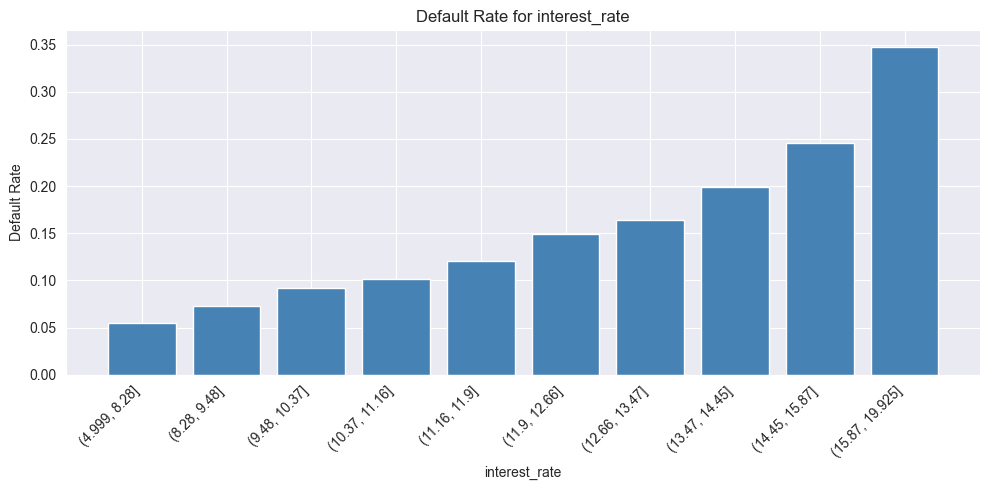

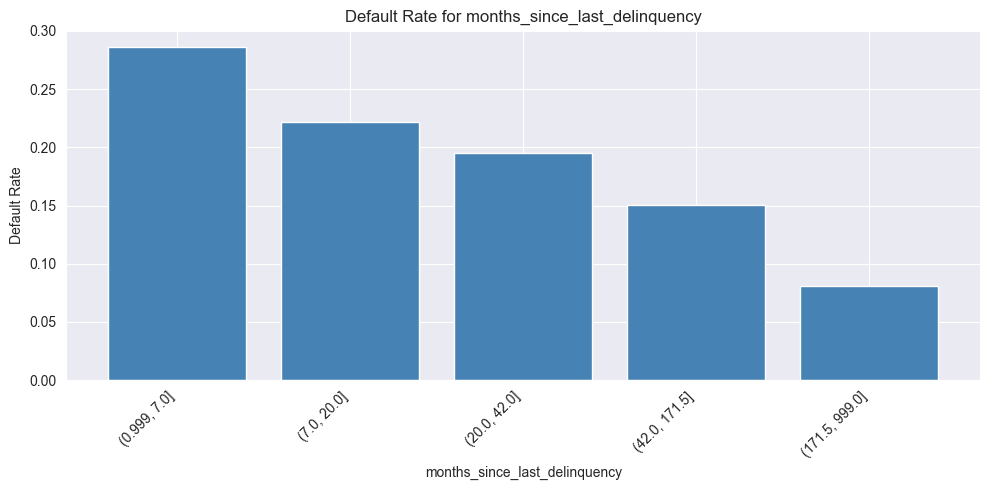

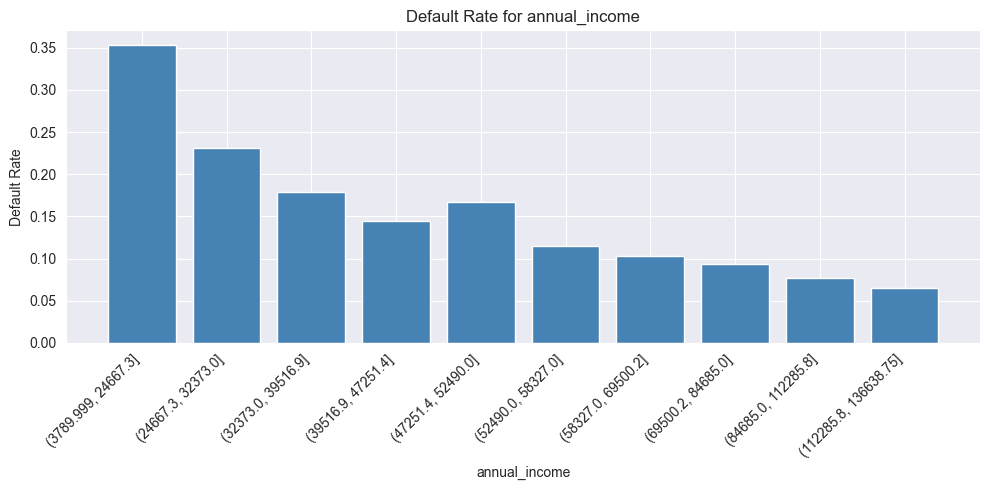

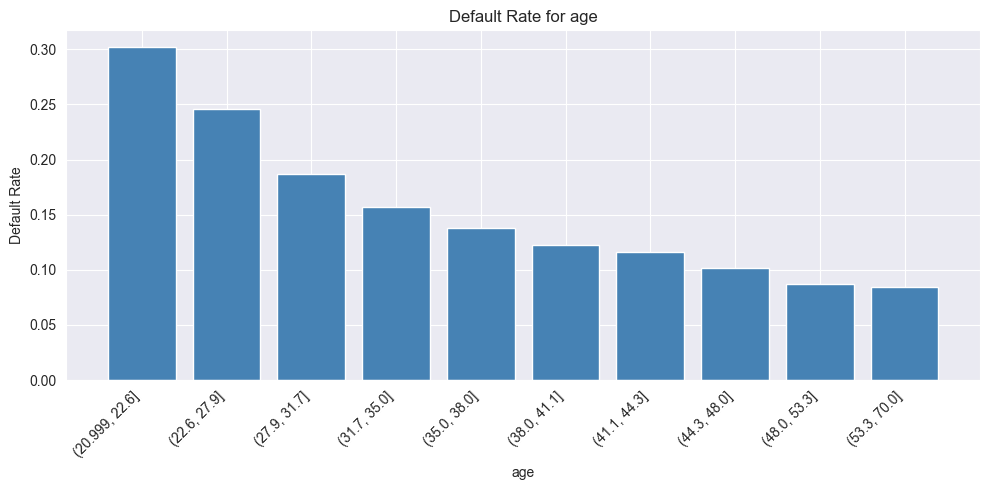

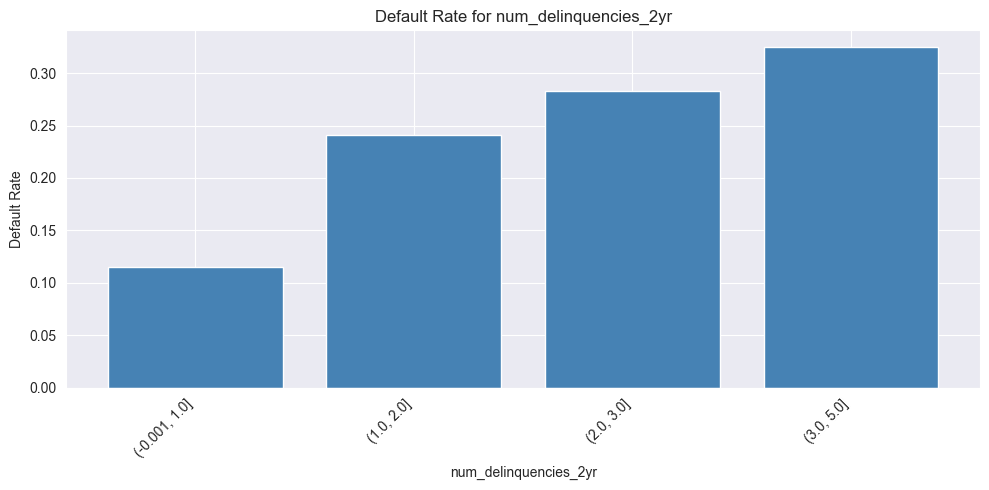

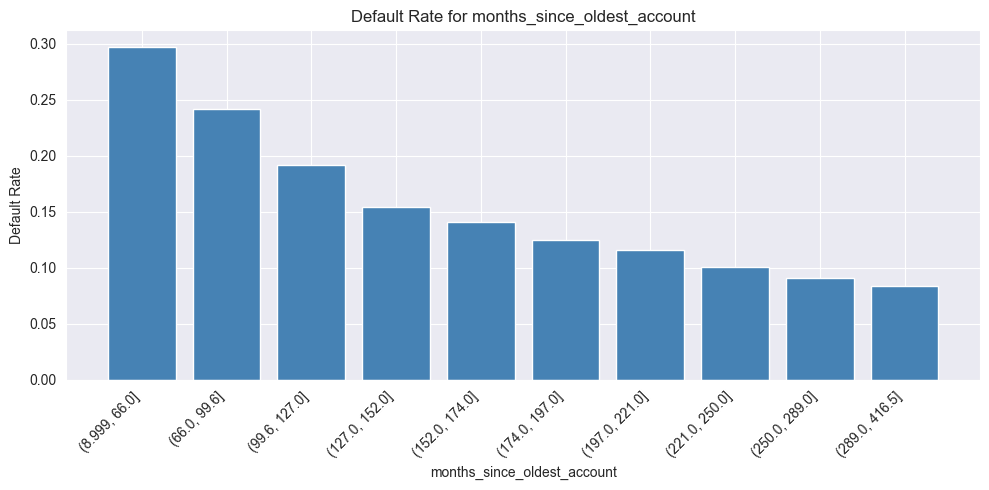

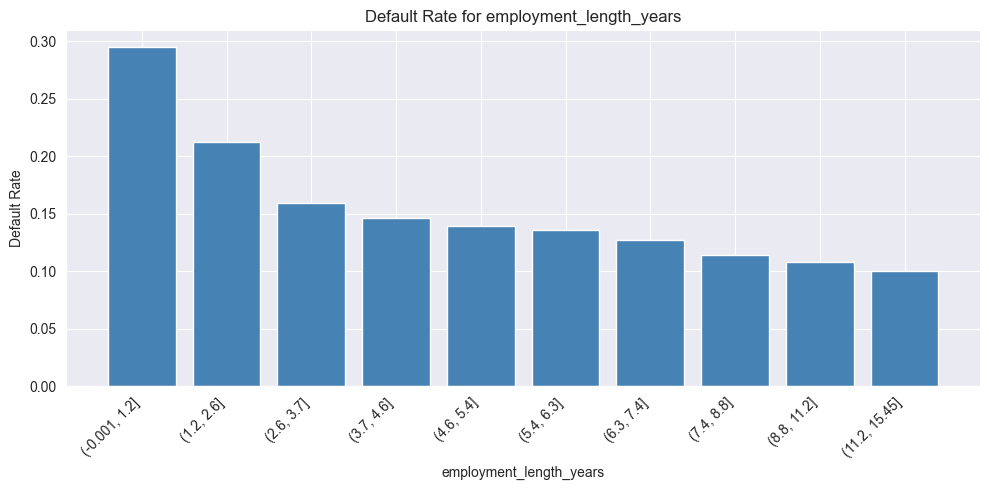

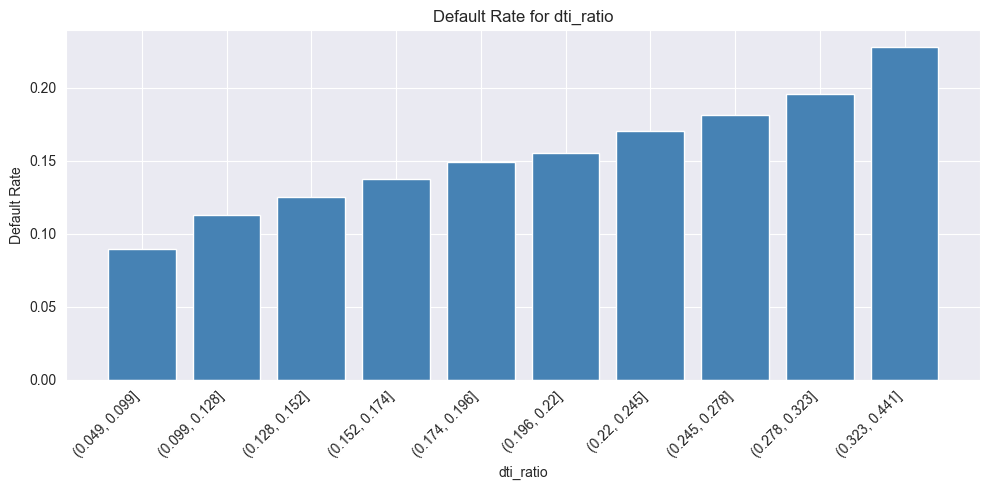

In [4]:
# Cell 4:  Plot default rate by bin for top 8 features

# top_features = [
#     'interest_rate',
#     'months_since_last_delinquency',
#     'annual_income',
#     'age',
#     'num_delinquencies_2yr',
#     'months_since_oldest_account'
# ]

top_features = [
    'interest_rate', 'months_since_last_delinquency', 'annual_income',
    'age', 'num_delinquencies_2yr', 'months_since_oldest_account',
    'employment_length_years', 'dti_ratio'
]

for feat in top_features:
    plot_default_rate_by_bin(train, feat)

In [5]:
# Cell 5:  Correlation check

corr = train[top_features].corr().round(2)
print(corr)

                               interest_rate  months_since_last_delinquency  \
interest_rate                           1.00                          -0.33   
months_since_last_delinquency          -0.33                           1.00   
annual_income                          -0.35                          -0.00   
age                                    -0.05                           0.00   
num_delinquencies_2yr                   0.50                          -0.64   
months_since_oldest_account            -0.05                           0.00   
employment_length_years                -0.04                           0.00   
dti_ratio                               0.43                           0.00   

                               annual_income   age  num_delinquencies_2yr  \
interest_rate                          -0.35 -0.05                   0.50   
months_since_last_delinquency          -0.00  0.00                  -0.64   
annual_income                           1.00  0.11       

In [9]:
# Cell 6:  Bivariate analysis

# Annual income and interest rate
train["income_group"] = pd.qcut(train["annual_income"], q=3, labels=["low", "medium", "high"])
train["rate_group"] = pd.qcut(train["interest_rate"], q=3, labels=["low", "medium", "high"])

income_rate_cross = train.groupby(["rate_group", "income_group"])["default_flag"].agg(
    default_rate="mean",
    count="count",
).reset_index()

print("Annual income and interest rate")
print(income_rate_cross.to_string(index=False))

# dti_ratio and annual income
train["dti_group"] = pd.qcut(train["dti_ratio"], q=3, labels=["low", "medium", "high"])

income_dti_cross = train.groupby(["dti_group", "income_group"])["default_flag"].agg(
    default_rate="mean",
    count="count",
).reset_index()

print("\nAnnual income and dti ratio")
print(income_dti_cross.to_string(index=False))

# Age and num_delinquencies_2yr
train["age_group"] = pd.qcut(train["age"], q=2, labels=["young", "old"])
train["deliq_2yr_group"] = pd.cut(train["num_delinquencies_2yr"],
                                  bins=[-1, 0, 2, 9], labels=["none", "some", "many"]
)

num_deliq_age_cross = train.groupby(["age_group", "deliq_2yr_group"])["default_flag"].agg(
    default_rate="mean",
    count="count",
).reset_index()

print("\nAge and num_delinquencies_2yr")
print(num_deliq_age_cross.to_string(index=False))




Annual income and interest rate
rate_group income_group  default_rate  count
       low          low      0.136399   5154
       low       medium      0.080545   9175
       low         high      0.050069  13821
    medium          low      0.185678   9398
    medium       medium      0.123054   9890
    medium         high      0.085902   8824
      high          low      0.327054  13536
      high       medium      0.213455   9023
      high         high      0.148815   5443

Annual income and dti ratio
dti_group income_group  default_rate  count
      low          low      0.200037   5374
      low       medium      0.115348   9467
      low         high      0.073774  13582
   medium          low      0.228016   9973
   medium       medium      0.135883   9545
   medium         high      0.081282   8329
     high          low      0.276744  12741
     high       medium      0.164500   9076
     high         high      0.094059   6177

Age and num_delinquencies_2yr
age_group deliq_2y